# 04_esrs_e1_checklist.ipynb
**Author:** Emma McCallum  
**Purpose:** Apply selected ESRS E1-inspired readiness indicators to BEGES data 
for five professional services firms  
**Input:** `data/processed/emissions_long.csv`, `data/processed/five_firms_full.csv`  
**Output:** `data/processed/esrs_scores.csv`, `figures/esrs_checklist.png`

## Important caveat

This notebook does not assess CSRD compliance. It applies selected ESRS E1-inspired 
readiness indicators to BEGES and ADEME structured data. A full ESRS E1 assessment 
would require the undertaking's sustainability statement, double materiality 
assessment, climate risks and opportunities, policies, financial effects, transition 
plan details, and assurance context. None of those are available in the ADEME export.

CSRD is already in force for Wave 1 firms. Wave 2 and Wave 3 reporting has been 
postponed by two years under the Stop-the-Clock Directive adopted in April 2025. 
The regulatory direction is clear even if exact timelines are shifting.

The question this notebook asks is: if these firms had to report under ESRS E1, 
how ready would their current BEGES be?

## ESRS E1 readiness criteria

Eight criteria are assessed, each scored 0 (not present) or 1 (present).
This is a binary scale because these elements either exist in the data or they do not.

| Criterion | What is checked | Data source |
|-----------|----------------|-------------|
| Scope 1 disclosed | Positive Scope 1 value reported | emissions_long.csv |
| Scope 2 disclosed | Positive Scope 2 value reported | emissions_long.csv |
| Scope 3 disclosed | Positive Scope 3 value reported | emissions_long.csv |
| Base year disclosed | Firm states a reference year | five_firms_full.csv |
| Near-term target | Reduction target for 2030 stated | five_firms_full.csv |
| Long-term target | 2050 or net zero target stated | five_firms_full.csv |
| Transition plan present | Action plan or climate strategy present | five_firms_full.csv |
| Scope 2 basis addressed | Location or market basis mentioned | five_firms_full.csv |

Maximum possible score: 8

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load emissions data for scope checks
emissions = pd.read_csv("../data/processed/emissions_long.csv")

# Load full firm data for text field checks
df = pd.read_csv("../data/processed/five_firms_full.csv")

# Keep most recent report per firm
df = df.sort_values("Année de reporting", ascending=False)
df = df.drop_duplicates(subset="Raison sociale", keep="first")

print(f"Firms loaded: {df['Raison sociale'].nunique()}")
print(f"Emissions rows: {len(emissions)}")
print()
print(df[["Raison sociale", "Année de reporting"]])

Firms loaded: 5
Emissions rows: 110

                Raison sociale  Année de reporting
5                   ECOCERT SA                2024
4  BUREAU VERITAS EXPLOITATION                2023
1                 ANTEA FRANCE                2023
6                      Eco CO2                2023
2                      ARTELIA                2022


In [2]:
name_map = {
    "BUREAU VERITAS EXPLOITATION": "Bureau Veritas",
    "ANTEA FRANCE": "Antea France",
    "ARTELIA": "Artelia",
    "ECOCERT SA": "Ecocert SA",
    "Eco CO2": "Eco CO2",
}

# Check scope disclosure from emissions_long.csv
scope_checks = emissions.groupby(["Raison sociale", "scope"])["tco2e"].sum().unstack(fill_value=0)

# Score 1 if any positive value exists for that scope
scope_scores = (scope_checks > 0).astype(int)
scope_scores.columns = ["scope_1", "scope_2", "scope_3"]
scope_scores.index = scope_scores.index.map(name_map)

print("Scope disclosure scores:")
print(scope_scores)

Scope disclosure scores:
                scope_1  scope_2  scope_3
Raison sociale                           
Antea France          1        1        1
Artelia               1        1        1
Bureau Veritas        1        0        1
Ecocert SA            1        1        1
Eco CO2               1        1        1


In [3]:
# Check text-based criteria from five_firms_full.csv

def has_content(text):
    if pd.isna(text):
        return 0
    return 1 if str(text).strip() != "" else 0

def mentions_keywords(text, keywords):
    if pd.isna(text):
        return 0
    text_lower = str(text).lower()
    return 1 if any(k in text_lower for k in keywords) else 0

results = []

for _, row in df.iterrows():
    firm = name_map.get(row["Raison sociale"], row["Raison sociale"])

    # Base year disclosed
    base_year = mentions_keywords(
    row["Une année de référence a été calculée"],
    ["oui", "yes"]
)

    # Near-term target
    target_2030 = has_content(row["Objectif de réduction pour 2030"])

    # Long-term target
    target_lt = has_content(row["Objectif de réduction pour 2050"])

    # Transition plan
    action_plan = has_content(row["Actions et moyens"])

    # Scope 2 basis addressed
    scope2_basis = mentions_keywords(
        row[df.columns[93]],
        ["location", "marché", "market", "localisation", "mix réseau", "mix"]
    )

    results.append({
        "firm": firm,
        "base_year": base_year,
        "target_2030": target_2030,
        "target_lt": target_lt,
        "action_plan": action_plan,
        "scope2_basis": scope2_basis,
    })

text_scores = pd.DataFrame(results).set_index("firm")
print(text_scores)

                base_year  target_2030  target_lt  action_plan  scope2_basis
firm                                                                        
Ecocert SA              0            0          0            1             0
Bureau Veritas          0            1          0            1             0
Antea France            0            0          0            1             0
Eco CO2                 0            1          1            1             0
Artelia                 1            1          0            1             0


In [4]:
# Combine all scores into one table
esrs_scores = pd.concat([scope_scores, text_scores], axis=1)

# Rename columns for clarity
esrs_scores.columns = [
    "Scope 1 disclosed",
    "Scope 2 disclosed",
    "Scope 3 disclosed",
    "Base year disclosed",
    "Near-term target (2030)",
    "Long-term target",
    "Transition plan present",
    "Scope 2 basis addressed",
]

# Add total row
esrs_scores.loc["TOTAL"] = esrs_scores.sum()

print(esrs_scores)

                Scope 1 disclosed  Scope 2 disclosed  Scope 3 disclosed  \
Antea France                    1                  1                  1   
Artelia                         1                  1                  1   
Bureau Veritas                  1                  0                  1   
Ecocert SA                      1                  1                  1   
Eco CO2                         1                  1                  1   
TOTAL                           5                  4                  5   

                Base year disclosed  Near-term target (2030)  \
Antea France                      0                        0   
Artelia                           1                        1   
Bureau Veritas                    0                        1   
Ecocert SA                        0                        0   
Eco CO2                           0                        1   
TOTAL                             1                        3   

                Long-term

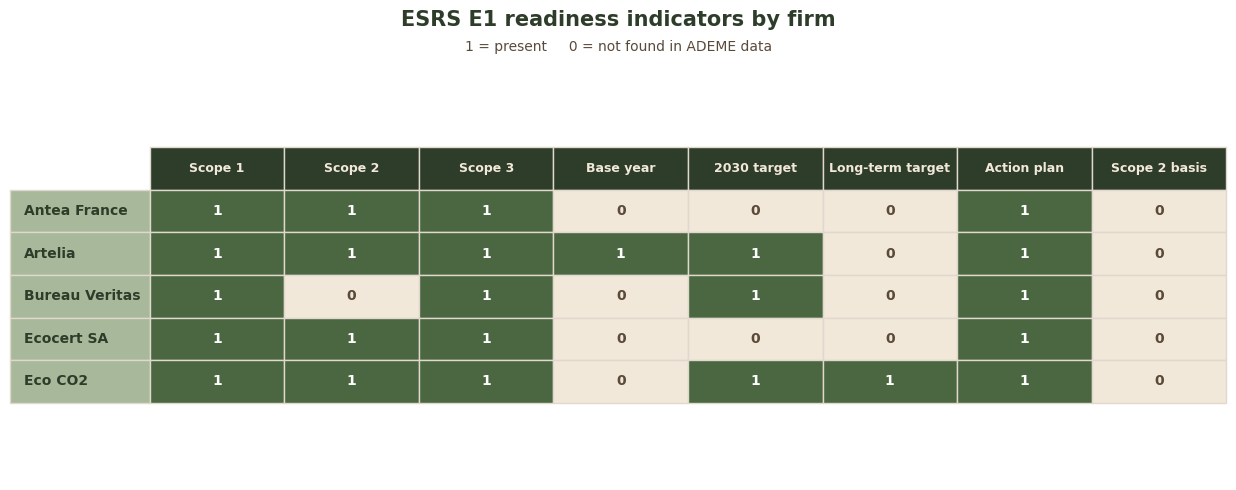

Saved.


In [5]:
plot_df = esrs_scores.drop("TOTAL").copy()

plot_df.columns = [
    "Scope 1",
    "Scope 2",
    "Scope 3",
    "Base year",
    "2030 target",
    "Long-term target",
    "Action plan",
    "Scope 2 basis",
]

colour_map = {0: "#f2e8d9", 1: "#4a6741"}
text_colour_map = {0: "#5a4a3a", 1: "white"}

fig, ax = plt.subplots(figsize=(13, 5))
ax.axis("off")

table = ax.table(
    cellText=plot_df.values,
    rowLabels=plot_df.index.tolist(),
    colLabels=plot_df.columns.tolist(),
    loc="center",
    cellLoc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.3, 2.4)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#e0d8cc")
    if row == 0:
        cell.set_facecolor("#2d3d2a")
        cell.set_text_props(fontweight="bold", color="#f2e8d9", fontsize=9)
    elif col == -1:
        cell.set_facecolor("#a8b89a")
        cell.set_text_props(fontweight="bold", color="#2d3d2a", fontsize=10)
    else:
        val = plot_df.values[row - 1][col]
        cell.set_facecolor(colour_map[val])
        cell.set_text_props(color=text_colour_map[val], fontweight="bold")

fig.text(
    0.5, 0.97,
    "ESRS E1 readiness indicators by firm",
    ha="center", va="top",
    fontsize=15, fontweight="bold", color="#2d3d2a"
)
fig.text(
    0.5, 0.91,
    "1 = present     0 = not found in ADEME data",
    ha="center", va="top",
    fontsize=10, color="#5a4a3a"
)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig("../figures/esrs_checklist.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

In [6]:
esrs_scores.to_csv("../data/processed/esrs_scores.csv")
print("Saved esrs_scores.csv")

import os
outputs = [
    "../figures/esrs_checklist.png",
    "../data/processed/esrs_scores.csv",
]
for path in outputs:
    exists = os.path.exists(path)
    size = os.path.getsize(path) if exists else 0
    print(f"{'OK' if exists else 'MISSING'}  {path}  ({size:,} bytes)")

Saved esrs_scores.csv
OK  ../figures/esrs_checklist.png  (51,925 bytes)
OK  ../data/processed/esrs_scores.csv  (321 bytes)


## Analytical findings

The ESRS E1 readiness check reveals a different pattern from the transparency
scoring in NB03. Firms that scored well on methodology transparency do not
necessarily show the strongest strategic climate disclosure in the ADEME fields.

All five firms disclose Scope 1 and Scope 3 emissions and provide an action
plan. Four of the five disclose Scope 2 emissions in the structured data.
However, only Artelia has a calculated reference year in the extracted fields.
The other four firms explicitly state that no reference year has been calculated,
which means progress against any stated reduction target cannot be formally
tracked from the structured data alone.

Bureau Veritas is the only firm without a positive Scope 2 value, which is
notable because Scope 2 disclosure is a core ESRS E1 emissions datapoint and
a basic expectation for organisations with offices, unless the emissions are
reported elsewhere or omitted from the structured export.

Beyond this baseline, readiness becomes uneven. Three firms disclose a
near-term 2030 reduction target, while only Eco CO2 discloses a long-term
climate target. No firm addresses the Scope 2 calculation basis in the ADEME
data, meaning none distinguishes between location-based and market-based
electricity emissions in the extracted fields. ESRS E1 expects Scope 2
emissions to be reported using both methods.

The most important systemic gaps are the absence of reference years for most
firms, the absence of long-term targets for four firms, and the complete
absence of Scope 2 methodology disclosure across all five. These are not minor
details. They indicate whether a firm's carbon inventory is connected to a
structured and trackable climate strategy rather than functioning only as a
regulatory emissions declaration.

Artelia and Eco CO2 score highest at 6 out of 8, for different reasons.
Artelia is the only firm with a calculated reference year. Eco CO2 is the
only firm with a long-term climate target. Bureau Veritas, Ecocert SA, and
Antea France each score 4 out of 8. The gap between firms is narrower here
than in NB02 or NB03, but the weaknesses are more consequential because they
relate to strategic climate readiness rather than reporting mechanics alone.

In [7]:
import pandas as pd

df = pd.read_csv("../data/processed/five_firms_full.csv")

# Keep most recent per firm
df = df.sort_values("Année de reporting", ascending=False)
df = df.drop_duplicates(subset="Raison sociale", keep="first")

name_map = {
    "BUREAU VERITAS EXPLOITATION": "Bureau Veritas",
    "ANTEA FRANCE": "Antea France",
    "ARTELIA": "Artelia",
    "ECOCERT SA": "Ecocert SA",
    "Eco CO2": "Eco CO2",
}

cols = {
    "2030 target": "Objectif de réduction pour 2030",
    "Long-term target": "Objectif de réduction pour 2050",
    "Action plan": "Actions et moyens",
}

for _, row in df.iterrows():
    firm = name_map.get(row["Raison sociale"], row["Raison sociale"])
    print("="*50)
    print(firm)
    print("="*50)
    for label, col in cols.items():
        val = row[col]
        if pd.isna(val) or str(val).strip() == "":
            print(f"{label}: [NOT DISCLOSED]")
        else:
            print(f"{label}: {str(val)[:200]}")
    print()

Ecocert SA
2030 target: [NOT DISCLOSED]
Long-term target: [NOT DISCLOSED]
Action plan: La gouvernance a été renforcée avec l’évolution du comité carbone et l’intégration de nouveaux membres :-Directeurs internationaux-Équipe RSE (projets climat et biodiversité)-Gestionnaire de mobilité 

Bureau Veritas
2030 target: -40% sur les scopes 1 et 2 et -25% sur le scope 3
Long-term target: [NOT DISCLOSED]
Action plan: En 2023, l’arrivée d’une nouvelle directrice des Achats, Mobilités et Immobilier a permis une nouvelle définition de son périmètre d’actions incluant également la RSE.Aussi, la gouvernance a été renfo

Antea France
2030 target: [NOT DISCLOSED]
Long-term target: [NOT DISCLOSED]
Action plan: Plan d&#039;actions en cours de validation ( Rapport RSE 2024).  Nos actions visent améliorer nos performances dans les thematiques suivntes: Les bonnes pratiques d’achat de bienLes deplacements profe

Eco CO2
2030 target: -18% des émissions à périmètre constant
Long-term target: -75% des émiss

In [8]:
import pandas as pd

emissions = pd.read_csv("../data/processed/emissions_long.csv")

for firm in emissions["Raison sociale"].unique():
    sub = emissions[emissions["Raison sociale"] == firm]
    sub = sub[sub["tco2e"] > 0].sort_values("tco2e", ascending=False)
    total = sub["tco2e"].sum()
    top2 = sub.head(2)["tco2e"].sum()
    rest_pct = round((total - top2) / total * 100, 1)
    print(f"{firm:<35} top2 share: {top2/total*100:.1f}%   rest: {rest_pct}%")

ANTEA FRANCE                        top2 share: 67.4%   rest: 32.6%
ARTELIA                             top2 share: 49.2%   rest: 50.8%
BUREAU VERITAS EXPLOITATION         top2 share: 91.7%   rest: 8.3%
ECOCERT SA                          top2 share: 41.1%   rest: 58.9%
Eco CO2                             top2 share: 91.6%   rest: 8.4%
